In [25]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder

from sklearn.preprocessing import RobustScaler

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("youtube_videos.csv")

In [6]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [7]:
df["subscribers"]

,subscribers
0,441016
1,25339
2,2398429
3,498144
4,30039
...,...
205,13428
206,10005
207,483919
208,11937


In [8]:
scaler = MinMaxScaler()

In [9]:
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

In [10]:
df["subscribers_minmax"].describe()

,subscribers_minmax
count,210.000000
mean,0.128853
std,0.265999
min,0.000000
25%,0.002555
50%,0.016794
75%,0.061946
max,1.000000


In [11]:
standard_scaler = StandardScaler()


In [12]:
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [13]:
df[["views","view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [14]:
df["log_views"] = np.log1p(df["views"])

<Axes: xlabel='log_views', ylabel='Count'>

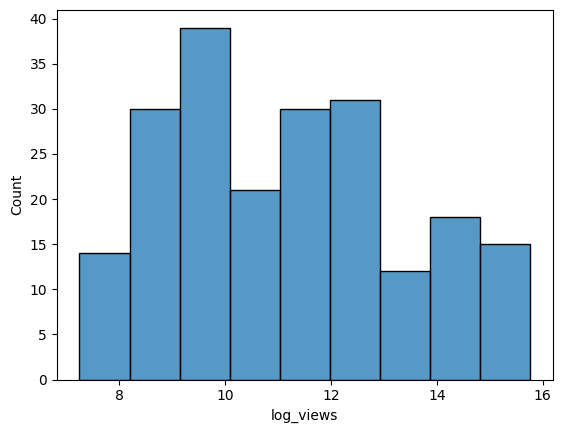

In [15]:
sns.histplot(df["log_views"])

<Axes: xlabel='likes_bin', ylabel='count'>

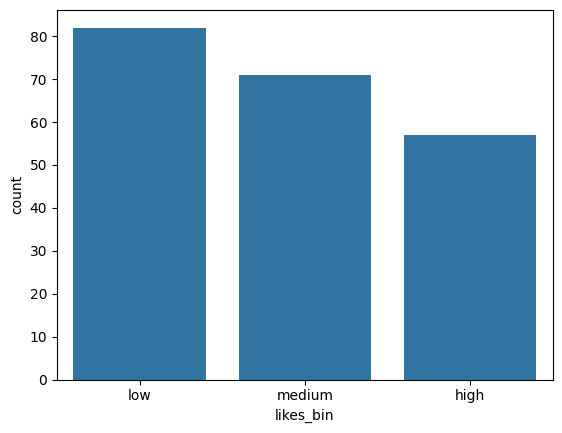

In [16]:


df["likes_bin"] = pd.cut(df["likes"], bins=[0,1000,10000,float("inf")], labels=["low","medium","high"])

sns.countplot(data=df, x="likes_bin", order=["low","medium","high"])

In [17]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [18]:
encoder = OrdinalEncoder(categories =[["Small","Mid", "Large"]])
df[["channel_tier_encoder"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

In [19]:
df[["channel_tier","channel"]]

KeyError: "['channel'] not in index"

In [20]:
dummyVars = pd.get_dummies(df["category"], prefix="is")

In [21]:
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

In [22]:
df["caps_count"]

,caps_count
0,3
1,1
2,0
3,0
4,4
...,...
205,3
206,2
207,0
208,2


In [23]:
def countCaps(t):
  sum = 0
  words = t.split()
  for word in words:
    if word.isupper():
      sum = sum+1

  return sum

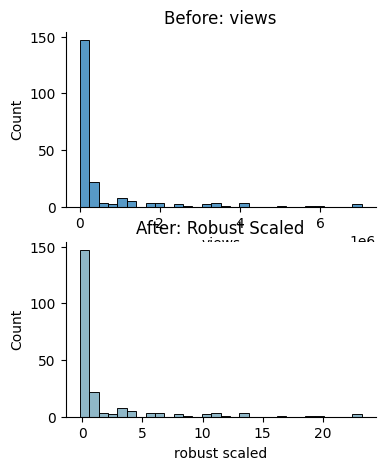

In [27]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df["views_robust"] = scaler.fit_transform(df[["views"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"], ax=axes[0], bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_robust"], ax=axes[1], color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.show()

In [29]:
ohe = pd.get_dummies(df["category"], prefix="is")

result = pd.concat([df[["video_id", "category"]], ohe], axis=1)

print(result.head(6).to_string(index=False))

video_id category  is_Comedy  is_Education  is_Gaming  is_Music  is_News  is_Vlog
vid_0000    Music      False         False      False      True    False    False
vid_0001   Gaming      False         False       True     False    False    False
vid_0002   Gaming      False         False       True     False    False    False
vid_0003   Gaming      False         False       True     False    False    False
vid_0004    Music      False         False      False      True    False    False
vid_0005     News      False         False      False     False     True    False
